In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib
import matplotlib.pyplot as plt
import pertpy as pt
import scanpy as sc
import pandas as pd
import seaborn as sb

plt.rcParams["figure.figsize"] = (7, 7)
import numpy as np

sc.settings.verbosity = 3


import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm, colors

#Define a nice colour map for gene expression
colors2 = plt.cm.plasma(np.linspace(0, 1, 128))
colors3 = plt.cm.Greys_r(np.linspace(0.7,0.8,20))
colorsComb = np.vstack([colors3, colors2])
mymap2 = colors.LinearSegmentedColormap.from_list('my_colormap', colorsComb)

## r2py setup
import rpy2.rinterface_lib.callbacks
import logging
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

%load_ext rpy2.ipython

## Define color palette
pal = sb.color_palette('Paired').as_hex()
design_palette = {'ACR':pal[3], 'CR':pal[7], 'AR':pal[9], 'joint_CR':pal[6]}
design_palette_df = pd.DataFrame(design_palette.values(), index =design_palette.keys() )
design_palette_df.columns = ['color']

import os,sys

figdir = './figures/'
if not os.path.exists(figdir):
    os.mkdir(figdir)
sc.settings.figdir = figdir

In [2]:
%%R
library(tidyverse)
library(reshape2)
library(patchwork)
library(ggrastr)
library(shadowtext)

remove_x_axis <- function(){
  theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(), axis.title.x = element_blank())  
}

remove_y_axis <- function(){
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(), axis.title.y = element_blank())  
}

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘reshape2’

The following object is masked from ‘package:tidyr’:

    smiths



In [3]:
%%R -i design_palette_df -i figdir
design_palette = setNames(design_palette_df$color, rownames(design_palette_df))

In [4]:
from adjustText import adjust_text
import matplotlib.patheffects as pe

def gen_mpl_labels(
    adata, groupby, exclude=(), ax=None, adjust_kwargs=None, text_kwargs=None
):
    if adjust_kwargs is None:
        adjust_kwargs = {"text_from_points": False}
    if text_kwargs is None:
        text_kwargs = {}

    medians = {}

    for g, g_idx in adata.obs.groupby(groupby).groups.items():
        if g in exclude:
            continue
        medians[g] = np.median(adata[g_idx].obsm["X_umap"], axis=0)

    if ax is None:
        texts = [
            plt.text(x=x, y=y, s=k, **text_kwargs) for k, (x, y) in medians.items()
        ]
    else:
        texts = [ax.text(x=x, y=y, s=k, **text_kwargs) for k, (x, y) in medians.items()]

    adjust_text(texts, **adjust_kwargs)

In [5]:
def plot_w_ggplot(r_fct_str, args, figdir='.', pl_name='plot', pl_width=8, pl_height=8):

    import rpy2.robjects.pandas2ri
    import rpy2.robjects.numpy2ri
    from rpy2.robjects.packages import STAP

    r_pkg = STAP(r_fct_str, "r_pkg")
    #this was needed for the code to run on jhub
    #if you have a different version of rpy2 you may not need these two lines
    rpy2.robjects.pandas2ri.activate()
    rpy2.robjects.numpy2ri.activate()
    
    # PASS OBJECTS INTO FUNCTION
    pl = r_pkg.plot_func(args)
    
    ggsave_str = '''
    save_plot <- function(pl, figdir, pl_name, pl_width, pl_height){
        pl + 
        ggsave(file.path(figdir, paste0(pl_name, ".png")), width=pl_width, height=pl_height)  +
        ggsave(file.path(figdir, paste0(pl_name, ".pdf")), width=pl_width, height=pl_height)
    }
    
    '''
    r_save = STAP(ggsave_str, "r_save")
    r_save.save_plot(pl, figdir, pl_name=pl_name, pl_width=pl_width, pl_height=pl_height)

# Read in all files for beeswarm MILO plots

In [6]:
NAWM = pd.read_csv('./nh_df_NAWM_all_revision.csv', index_col=1)  # index_col=0 to set the first column as the index
NAWM.shape

(15526, 12)

In [7]:
AL = pd.read_csv('./nh_df_AL_all_revision.csv', index_col=1)  # index_col=0 to set the first column as the index
AL.shape

(15526, 12)

In [8]:
CAL = pd.read_csv('./nh_df_CAL_revisions.csv', index_col=1)  # index_col=0 to set the first column as the index
CAL.shape

(15526, 12)

In [9]:
CIL = pd.read_csv('./nh_df_CIL_revisions.csv', index_col=1)  # index_col=0 to set the first column as the index
CIL.shape

(15526, 12)

In [10]:
RL = pd.read_csv('./nh_df_RL_revisions.csv', index_col=1)  # index_col=0 to set the first column as the index
RL.shape

(15526, 12)

In [11]:
RL.head()

,Unnamed: 0,kth_distance,logFC,logCPM,F,PValue,FDR,SpatialFDR,Sig,Nhood_size,nhood_annotation,nhood_annotation_frac
index_cell,,,,,,,,,,,,
Ind98-Sample2:AACCACAAGCAGGCTA-1,0,0.832988,0.754430,6.868654,1.048437,0.306876,0.563178,0.579574,False,424.0,MOL_A,0.653302
Ind98-Sample2:ACCACAAGTATTGCCA-1,1,0.732247,-2.304221,6.588119,4.199851,0.041496,0.155169,0.167338,False,358.0,OPCs,1.000000
Ind98-Sample2:ACGATCAAGCCACCGT-1,2,0.812018,-0.113871,6.618703,0.018632,0.891534,0.953444,0.955506,False,457.0,MOL_B,0.842451
Ind98-Sample2:ACGGTTATCACCGACG-1,3,0.704394,-1.652479,6.937533,2.516698,0.113921,0.308411,0.326091,False,433.0,OPCs,1.000000
Ind98-Sample2:ACGTCCTGTCCCACGA-1,4,1.070089,-3.509108,6.619688,9.186939,0.002688,0.022306,0.025298,True,363.0,MOL_A,1.000000


In [12]:
RL.shape

(15526, 12)

In [13]:
# Drop rows where the 'nhood_annotation' column has the value 'Mixed'
NAWM = NAWM[NAWM['nhood_annotation'] != 'Mixed']
AL = AL[AL['nhood_annotation'] != 'Mixed']
CAL = CAL[CAL['nhood_annotation'] != 'Mixed']
CIL = CIL[CIL['nhood_annotation'] != 'Mixed']
RL = RL[RL['nhood_annotation'] != 'Mixed']

# Check the shape after dropping the rows
RL.shape

(12049, 12)

# Observe stacked bar charts:

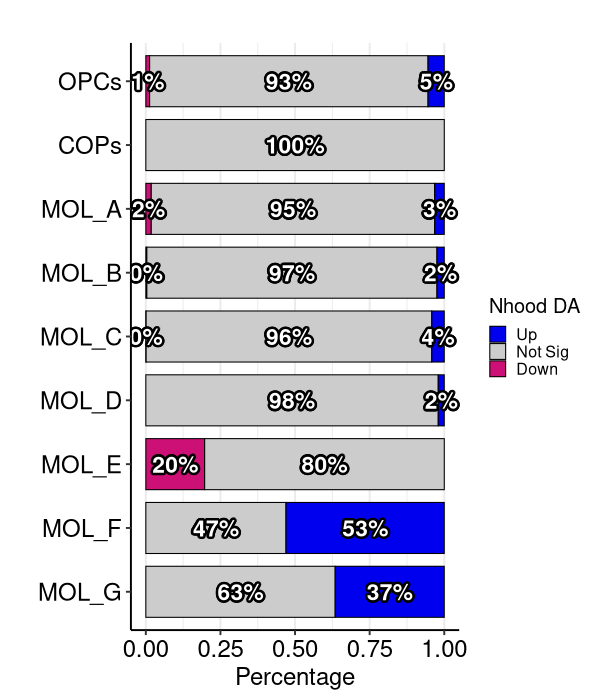

In [23]:
%%R -h 700 -w 600 -i NAWM

## FINAL PLOT ##

# Define desired order
desired_order <- rev(c(
  "OPCs", "COPs", "MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- NAWM %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))  # ensure stacking order
  )

# Calculate label positions based on the stacking order
plot_df_with_labels <- plot_df %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%  # Reverse order: Down, Not Sig, Up
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup()

# Plot stacked bar chart
p <- ggplot(plot_df_with_labels, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.8, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = scales::percent(proportion, accuracy = 1)),
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.15,           # Radius of outline
      size = 8,
      fontface = "bold"
    ) +
  coord_flip() +
  scale_fill_manual(
    values = c("Down" = "deeppink3", "Not Sig" = "grey80", "Up" = "blue2"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 24),             # x-axis tick label size
    axis.text.y = element_text(size = 24),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("Percentage") +
  xlab("") +
  ggtitle("")

# Save the plot
ggsave(paste0(figdir, "stacked_bar_proportions_NAWM.png"), plot = p, width = 14, height = 10, dpi = 300)

# Display the plot
print(p)

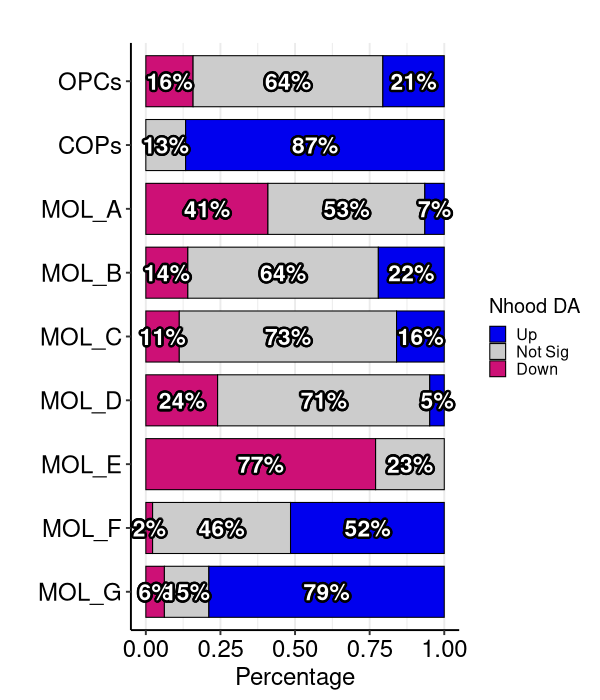

In [22]:
%%R -h 700 -w 600 -i AL

## FINAL PLOT ##

# Define desired order
desired_order <- rev(c(
  "OPCs", "COPs", "MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- AL %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))  # ensure stacking order
  )

# Calculate label positions based on the stacking order
plot_df_with_labels <- plot_df %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%  # Reverse order: Down, Not Sig, Up
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup()

# Plot stacked bar chart
p <- ggplot(plot_df_with_labels, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.8, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = scales::percent(proportion, accuracy = 1)),
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.15,           # Radius of outline
      size = 8,
      fontface = "bold"
    ) +
  coord_flip() +
  scale_fill_manual(
    values = c("Down" = "deeppink3", "Not Sig" = "grey80", "Up" = "blue2"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 24),             # x-axis tick label size
    axis.text.y = element_text(size = 24),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("Percentage") +
  xlab("") +
  ggtitle("")

# Save the plot
ggsave(paste0(figdir, "stacked_bar_proportions_AL.png"), plot = p, width = 14, height = 10, dpi = 300)

# Display the plot
print(p)

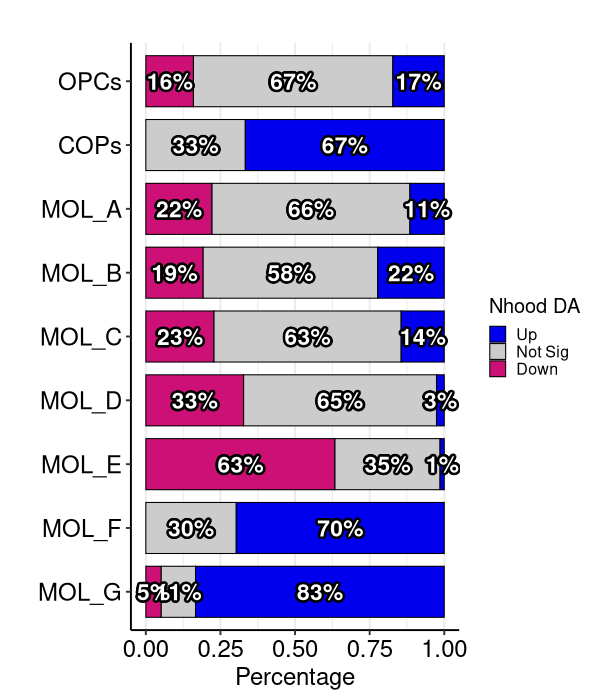

In [21]:
%%R -h 700 -w 600 -i CAL

## FINAL PLOT ##

# Define desired order
desired_order <- rev(c(
  "OPCs", "COPs", "MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- CAL %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))  # ensure stacking order
  )

# Calculate label positions based on the stacking order
plot_df_with_labels <- plot_df %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%  # Reverse order: Down, Not Sig, Up
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup()

# Plot stacked bar chart
p <- ggplot(plot_df_with_labels, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.8, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = scales::percent(proportion, accuracy = 1)),
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.15,           # Radius of outline
      size = 8,
      fontface = "bold"
    ) +
  coord_flip() +
  scale_fill_manual(
    values = c("Down" = "deeppink3", "Not Sig" = "grey80", "Up" = "blue2"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 24),             # x-axis tick label size
    axis.text.y = element_text(size = 24),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("Percentage") +
  xlab("") +
  ggtitle("")

# Save the plot
ggsave(paste0(figdir, "stacked_bar_proportions_CAL.png"), plot = p, width = 14, height = 10, dpi = 300)

# Display the plot
print(p)

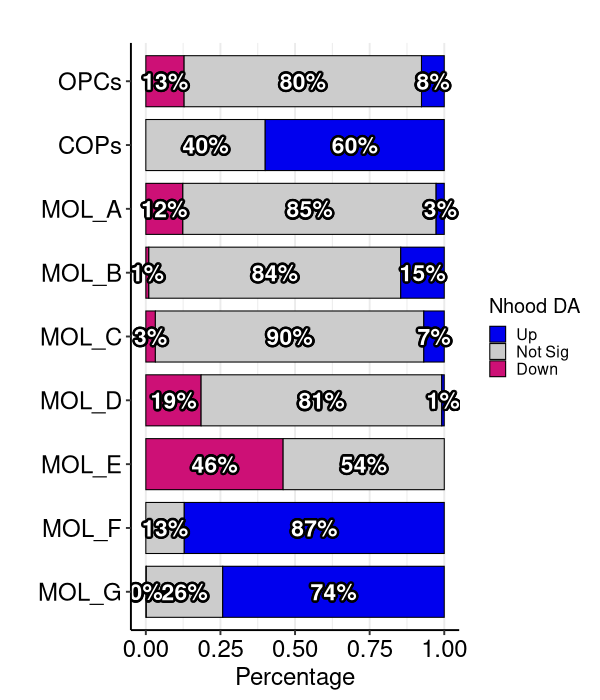

In [20]:
%%R -h 700 -w 600 -i CIL

## FINAL PLOT ##

# Define desired order
desired_order <- rev(c(
  "OPCs", "COPs", "MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- CIL %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))  # ensure stacking order
  )

# Calculate label positions based on the stacking order
plot_df_with_labels <- plot_df %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%  # Reverse order: Down, Not Sig, Up
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup()

# Plot stacked bar chart
p <- ggplot(plot_df_with_labels, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.8, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = scales::percent(proportion, accuracy = 1)),
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.15,           # Radius of outline
      size = 8,
      fontface = "bold"
    ) +
  coord_flip() +
  scale_fill_manual(
    values = c("Down" = "deeppink3", "Not Sig" = "grey80", "Up" = "blue2"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 24),             # x-axis tick label size
    axis.text.y = element_text(size = 24),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("Percentage") +
  xlab("") +
  ggtitle("")

# Save the plot
ggsave(paste0(figdir, "stacked_bar_proportions_CIL.png"), plot = p, width = 14, height = 10, dpi = 300)

# Display the plot
print(p)

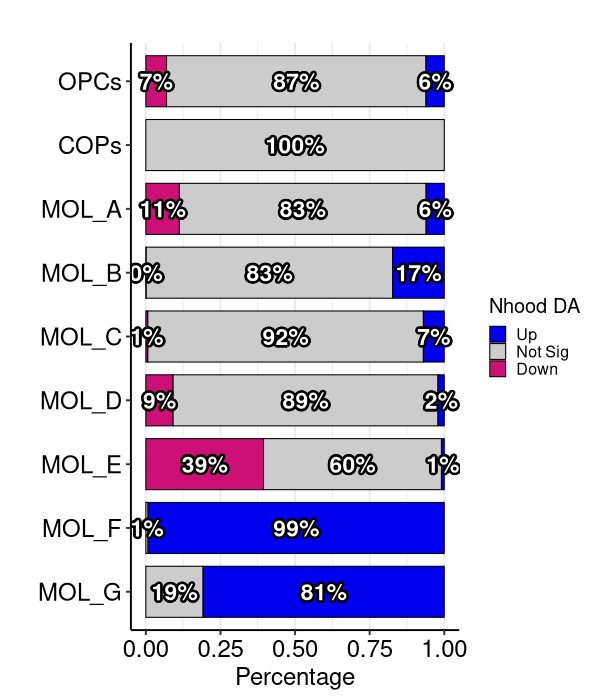

In [19]:
%%R -h 700 -w 600 -i RL

## FINAL PLOT ##

# Define desired order
desired_order <- rev(c(
  "OPCs", "COPs", "MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data
plot_df <- RL %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))  # ensure stacking order
  )

# Calculate label positions based on the stacking order
plot_df_with_labels <- plot_df %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%  # Reverse order: Down, Not Sig, Up
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup()

# Plot stacked bar chart
p <- ggplot(plot_df_with_labels, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.8, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = scales::percent(proportion, accuracy = 1)),
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.15,           # Radius of outline
      size = 8,
      fontface = "bold"
    ) +
  coord_flip() +
  scale_fill_manual(
    values = c("Down" = "deeppink3", "Not Sig" = "grey80", "Up" = "blue2"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 24),             # x-axis tick label size
    axis.text.y = element_text(size = 24),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("Percentage") +
  xlab("") +
  ggtitle("")

# Save the plot
ggsave(paste0(figdir, "stacked_bar_proportions_RL.png"), plot = p, width = 14, height = 10, dpi = 300)

# Display the plot
print(p)

# Plot with stats: pairwise comaprisons only

In [14]:
%%R -i AL
AL %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  filter(nhood_annotation == "COPs") %>%
  count(sig_status)

  sig_status  n
1    Not Sig  2
2         Up 13


In [15]:
%%R -i NAWM
NAWM %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  filter(nhood_annotation == "COPs") %>%
  count(sig_status)

  sig_status  n
1    Not Sig 15


In [16]:
%%R -i CAL
CAL %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  filter(nhood_annotation == "COPs") %>%
  count(sig_status)

  sig_status  n
1    Not Sig  5
2         Up 10


In [17]:
%%R -i CIL
CIL %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  filter(nhood_annotation == "COPs") %>%
  count(sig_status)

  sig_status n
1    Not Sig 6
2         Up 9


In [19]:
%%R -i RL
RL %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  filter(nhood_annotation == "COPs") %>%
  count(sig_status)

  sig_status  n
1    Not Sig 15


In [30]:
%%R

# Function to prepare a dataset
prepare_df <- function(df, condition_label) {
  df %>%
    mutate(
      sig_status = case_when(
        SpatialFDR < 0.1 & logFC > 0 ~ "Up",
        SpatialFDR < 0.1 & logFC < 0 ~ "Down",
        TRUE ~ "Not Sig"
      )
    ) %>%
    group_by(nhood_annotation, sig_status) %>%
    summarise(n = n(), .groups = "drop") %>%
    mutate(condition = condition_label)
}

# Main function to process two datasets and run tests
compare_conditions <- function(df1, df2, label1 = "Condition1", label2 = "Condition2", output_csv = NULL) {
  # Prepare both datasets
  df1_prepared <- prepare_df(df1, label1)
  df2_prepared <- prepare_df(df2, label2)
  
  # Combine
  combined_df <- bind_rows(df1_prepared, df2_prepared)
  
  # Compute totals per cell type and condition
  totals_df <- combined_df %>%
    group_by(nhood_annotation, condition) %>%
    summarise(total_n = sum(n), .groups = "drop")
  
  # Merge totals back
  combined_df <- combined_df %>%
    left_join(totals_df, by = c("nhood_annotation", "condition"))
  
  # Function to run Fisher or Chi-squared
  test_fn <- function(cell, status) {
    sub_df <- combined_df %>%
      filter(nhood_annotation == cell, sig_status == status)
    
    if (nrow(sub_df) != 2) {
      return(tibble(
        nhood_annotation = cell,
        sig_status = status,
        Condition1_count = NA,
        Condition1_total = NA,
        Condition1_prop = NA,
        Condition2_count = NA,
        Condition2_total = NA,
        Condition2_prop = NA,
        p_value = NA,
        test_used = NA
      ))
    }
    
    counts <- sub_df$n
    totals <- sub_df$total_n
    
    mat <- matrix(
      c(
        counts[1], totals[1] - counts[1],
        counts[2], totals[2] - counts[2]
      ),
      nrow = 2,
      byrow = TRUE
    )
    
    row_totals <- rowSums(mat)
    col_totals <- colSums(mat)
    grand_total <- sum(mat)
    expected <- outer(row_totals, col_totals) / grand_total
    
    if (any(expected < 5)) {
      test <- fisher.test(mat)
      test_name <- "Fisher"
    } else {
      test <- chisq.test(mat, simulate.p.value = FALSE, correct = FALSE)
      test_name <- "Chi-squared"
    }
    
    tibble(
      nhood_annotation = cell,
      sig_status = status,
      Condition1_count = counts[1],
      Condition1_total = totals[1],
      Condition1_prop = counts[1]/totals[1],
      Condition2_count = counts[2],
      Condition2_total = totals[2],
      Condition2_prop = counts[2]/totals[2],
      p_value = test$p.value,
      test_used = test_name
    )
  }
  
  # All unique combinations
  combinations <- combined_df %>%
    distinct(nhood_annotation, sig_status)
  
  # Run tests
  results <- pmap_dfr(
    list(combinations$nhood_annotation, combinations$sig_status),
    test_fn
  )
  
  # Adjust p-values
  results <- results %>%
    mutate(p_adj = p.adjust(p_value, method = "BH"))
  
  # Which condition has more
  results <- results %>%
    mutate(
      condition_with_more = case_when(
        is.na(Condition1_prop) | is.na(Condition2_prop) ~ NA_character_,
        Condition1_prop > Condition2_prop ~ label1,
        Condition1_prop < Condition2_prop ~ label2,
        Condition1_prop == Condition2_prop ~ "Equal"
      )
    )
  
  # Significance labels
  results <- results %>%
    mutate(
      significance = case_when(
        is.na(p_adj) ~ NA_character_,
        p_adj < 0.01 ~ "** (p < 0.01)",
        p_adj < 0.05 ~ "* (p < 0.05)",
        TRUE ~ ""
      )
    )
  
  # Output
  print(results, n = Inf)
  
  if (!is.null(output_csv)) {
    write.csv(results, output_csv, row.names = FALSE)
  }
  
  return(results)
}

# Run:
results <- compare_conditions(AL, RL, label1 = "AL", label2 = "RL", output_csv = "pairwise_fisher_chisq_results_AL_RL.csv")

# A tibble: 26 × 13
   nhood_annotation sig_status Condition1_count Condition1_total Condition1_prop
   <chr>            <chr>                 <int>            <int>           <dbl>
 1 COPs             Not Sig                   2               15          0.133 
 2 COPs             Up                       NA               NA         NA     
 3 MOL_A            Down                    854             2087          0.409 
 4 MOL_A            Not Sig                1097             2087          0.526 
 5 MOL_A            Up                      136             2087          0.0652
 6 MOL_B            Down                    501             3558          0.141 
 7 MOL_B            Not Sig                2271             3558          0.638 
 8 MOL_B            Up                      786             3558          0.221 
 9 MOL_C            Down                    319             2845          0.112 
10 MOL_C            Not Sig                2071             2845          0.728 
11 MOL_C

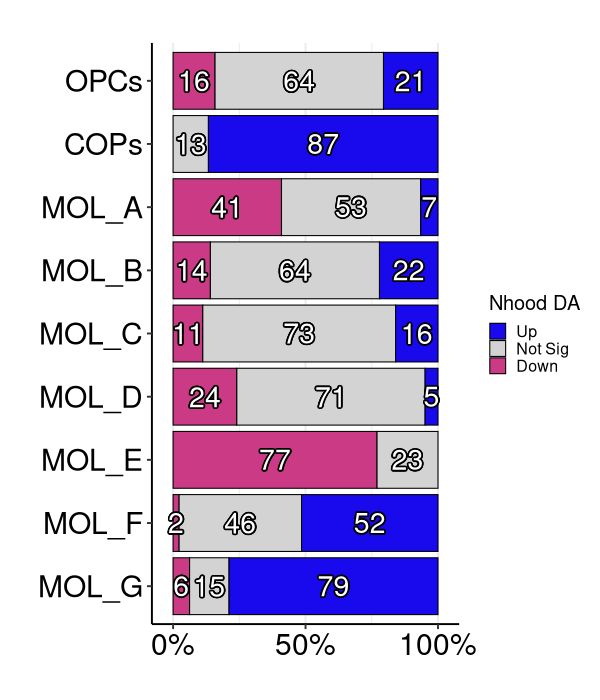

In [32]:
%%R -h 700 -w 600

## LR PLOT ##
# Define desired order
desired_order <- rev(c(
  "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data for LR
plot_df_LR <- AL %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  )

# Filter results for LR and Up/Down only
sig_results_LR <- results %>%
  filter(condition_with_more == "AL", sig_status %in% c("Up", "Down")) %>%
  select(nhood_annotation, sig_status, significance)

# Join and PRESERVE factor levels for LR
plot_df_with_labels_LR <- plot_df_LR %>% 
  left_join(
    sig_results_LR,
    by = c("nhood_annotation", "sig_status")
  ) %>%
  # Re-establish factor levels after join
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  ) %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup() %>%
    mutate(
        label = paste0("'", round(proportion * 100), "'")
    )

# Plot stacked bar chart
p_LR <- ggplot(plot_df_with_labels_LR, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.9, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = label),
      parse = TRUE,
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.08,           # Radius of outline
      size = 10,
      fontface = "bold"
    ) +
  coord_flip() +
    scale_y_continuous(
      limits = c(0, 1),
      expand = expansion(mult = c(0.08, 0.08)),
      breaks = c(0, 0.5, 1),
      labels = scales::percent_format(accuracy = 1)
    ) +
  scale_fill_manual(
    values = c("Down" = "#CA3A85", "Not Sig" = "#D3D3D3", "Up" = "#180AEC"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 30),             # x-axis tick label size
    axis.text.y = element_text(size = 30),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("") +
  xlab("") +
  ggtitle("")

# Save the LR plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_AL_vRL_remyel_SIG_UPDATED.png"),
  plot = p_LR,
  width = 10,
  height = 10,
  dpi = 300
)

# Display the LR plot
print(p_LR)

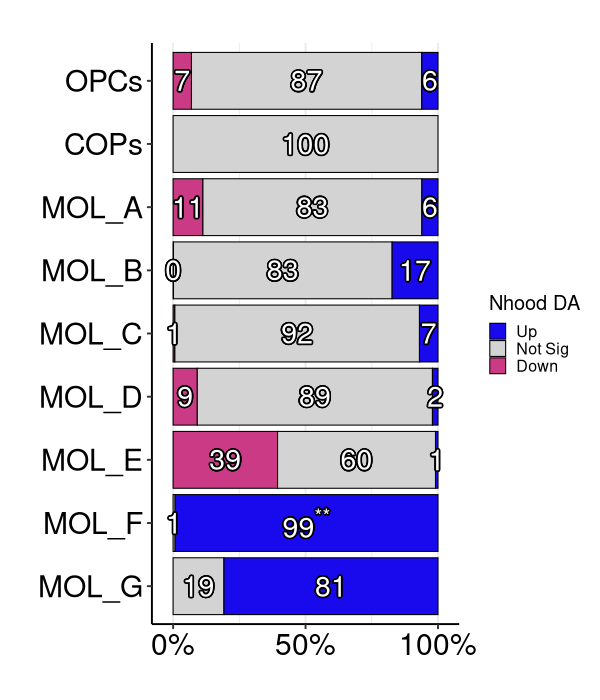

In [23]:
%%R -h 700 -w 600

## LR PLOT ##
# Define desired order
desired_order <- rev(c(
  "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data for LR
plot_df_LR <- RL %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  )

# Filter results for LR and Up/Down only
sig_results_LR <- results %>%
  filter(condition_with_more == "RL", sig_status %in% c("Up", "Down")) %>%
  select(nhood_annotation, sig_status, significance)

# Join and PRESERVE factor levels for LR
plot_df_with_labels_LR <- plot_df_LR %>% 
  left_join(
    sig_results_LR,
    by = c("nhood_annotation", "sig_status")
  ) %>%
  # Re-establish factor levels after join
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  ) %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup() %>%
    mutate(
        label = case_when(
          is.na(significance) ~ paste0("'", round(proportion * 100), "'"),
          significance == "* (p < 0.05)" ~ paste0("'", round(proportion * 100), "'^'*'"),
          significance == "** (p < 0.01)" ~ paste0("'", round(proportion * 100), "'^'**'"),
          TRUE ~ paste0("'", round(proportion * 100), "'")
        )
    )

# Plot stacked bar chart
p_LR <- ggplot(plot_df_with_labels_LR, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.9, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = label),
      parse = TRUE,
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.08,           # Radius of outline
      size = 10,
      fontface = "bold"
    ) +
  coord_flip() +
    scale_y_continuous(
      limits = c(0, 1),
      expand = expansion(mult = c(0.08, 0.08)),
      breaks = c(0, 0.5, 1),
      labels = scales::percent_format(accuracy = 1)
    ) +
  scale_fill_manual(
    values = c("Down" = "#CA3A85", "Not Sig" = "#D3D3D3", "Up" = "#180AEC"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 30),             # x-axis tick label size
    axis.text.y = element_text(size = 30),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("") +
  xlab("") +
  ggtitle("")

# Save the LR plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_RL_remyel_SIG_UPDATED.png"),
  plot = p_LR,
  width = 10,
  height = 10,
  dpi = 300
)

# Display the LR plot
print(p_LR)

In [24]:
%%R -i AL -i CAL

# Function to prepare a dataset
prepare_df <- function(df, condition_label) {
  df %>%
    mutate(
      sig_status = case_when(
        SpatialFDR < 0.1 & logFC > 0 ~ "Up",
        SpatialFDR < 0.1 & logFC < 0 ~ "Down",
        TRUE ~ "Not Sig"
      )
    ) %>%
    group_by(nhood_annotation, sig_status) %>%
    summarise(n = n(), .groups = "drop") %>%
    mutate(condition = condition_label)
}

# Main function to process two datasets and run tests
compare_conditions <- function(df1, df2, label1 = "Condition1", label2 = "Condition2", output_csv = NULL) {
  # Prepare both datasets
  df1_prepared <- prepare_df(df1, label1)
  df2_prepared <- prepare_df(df2, label2)
  
  # Combine
  combined_df <- bind_rows(df1_prepared, df2_prepared)
  
  # Compute totals per cell type and condition
  totals_df <- combined_df %>%
    group_by(nhood_annotation, condition) %>%
    summarise(total_n = sum(n), .groups = "drop")
  
  # Merge totals back
  combined_df <- combined_df %>%
    left_join(totals_df, by = c("nhood_annotation", "condition"))
  
  # Function to run Fisher or Chi-squared
  test_fn <- function(cell, status) {
    sub_df <- combined_df %>%
      filter(nhood_annotation == cell, sig_status == status)
    
    if (nrow(sub_df) != 2) {
      return(tibble(
        nhood_annotation = cell,
        sig_status = status,
        Condition1_count = NA,
        Condition1_total = NA,
        Condition1_prop = NA,
        Condition2_count = NA,
        Condition2_total = NA,
        Condition2_prop = NA,
        p_value = NA,
        test_used = NA
      ))
    }
    
    counts <- sub_df$n
    totals <- sub_df$total_n
    
    mat <- matrix(
      c(
        counts[1], totals[1] - counts[1],
        counts[2], totals[2] - counts[2]
      ),
      nrow = 2,
      byrow = TRUE
    )
    
    row_totals <- rowSums(mat)
    col_totals <- colSums(mat)
    grand_total <- sum(mat)
    expected <- outer(row_totals, col_totals) / grand_total
    
    if (any(expected < 5)) {
      test <- fisher.test(mat)
      test_name <- "Fisher"
    } else {
      test <- chisq.test(mat, simulate.p.value = FALSE, correct = FALSE)
      test_name <- "Chi-squared"
    }
    
    tibble(
      nhood_annotation = cell,
      sig_status = status,
      Condition1_count = counts[1],
      Condition1_total = totals[1],
      Condition1_prop = counts[1]/totals[1],
      Condition2_count = counts[2],
      Condition2_total = totals[2],
      Condition2_prop = counts[2]/totals[2],
      p_value = test$p.value,
      test_used = test_name
    )
  }
  
  # All unique combinations
  combinations <- combined_df %>%
    distinct(nhood_annotation, sig_status)
  
  # Run tests
  results <- pmap_dfr(
    list(combinations$nhood_annotation, combinations$sig_status),
    test_fn
  )
  
  # Adjust p-values
  results <- results %>%
    mutate(p_adj = p.adjust(p_value, method = "BH"))
  
  # Which condition has more
  results <- results %>%
    mutate(
      condition_with_more = case_when(
        is.na(Condition1_prop) | is.na(Condition2_prop) ~ NA_character_,
        Condition1_prop > Condition2_prop ~ label1,
        Condition1_prop < Condition2_prop ~ label2,
        Condition1_prop == Condition2_prop ~ "Equal"
      )
    )
  
  # Significance labels
  results <- results %>%
    mutate(
      significance = case_when(
        is.na(p_adj) ~ NA_character_,
        p_adj < 0.01 ~ "** (p < 0.01)",
        p_adj < 0.05 ~ "* (p < 0.05)",
        TRUE ~ ""
      )
    )
  
  # Output
  print(results, n = Inf)
  
  if (!is.null(output_csv)) {
    write.csv(results, output_csv, row.names = FALSE)
  }
  
  return(results)
}

# Run:
results <- compare_conditions(AL, CAL, label1 = "AL", label2 = "CAL", output_csv = "pairwise_fisher_chisq_results_AL_CAL.csv")

# A tibble: 26 × 13
   nhood_annotation sig_status Condition1_count Condition1_total Condition1_prop
   <chr>            <chr>                 <int>            <int>           <dbl>
 1 COPs             Not Sig                   2               15          0.133 
 2 COPs             Up                       13               15          0.867 
 3 MOL_A            Down                    854             2087          0.409 
 4 MOL_A            Not Sig                1097             2087          0.526 
 5 MOL_A            Up                      136             2087          0.0652
 6 MOL_B            Down                    501             3558          0.141 
 7 MOL_B            Not Sig                2271             3558          0.638 
 8 MOL_B            Up                      786             3558          0.221 
 9 MOL_C            Down                    319             2845          0.112 
10 MOL_C            Not Sig                2071             2845          0.728 
11 MOL_C

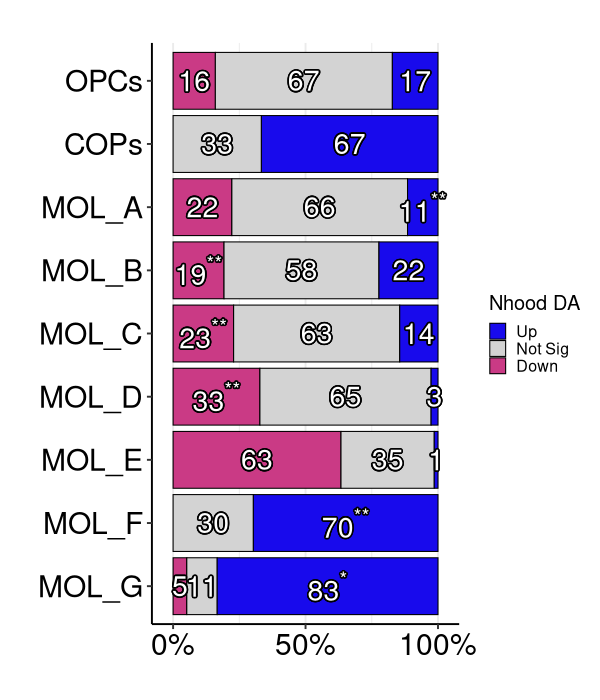

In [25]:
%%R -h 700 -w 600

## LR PLOT ##
# Define desired order
desired_order <- rev(c(
  "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data for LR
plot_df_LR <- CAL %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  )

# Filter results for LR and Up/Down only
sig_results_LR <- results %>%
  filter(condition_with_more == "CAL", sig_status %in% c("Up", "Down")) %>%
  select(nhood_annotation, sig_status, significance)

# Join and PRESERVE factor levels for LR
plot_df_with_labels_LR <- plot_df_LR %>% 
  left_join(
    sig_results_LR,
    by = c("nhood_annotation", "sig_status")
  ) %>%
  # Re-establish factor levels after join
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  ) %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup() %>%
    mutate(
        label = case_when(
          is.na(significance) ~ paste0("'", round(proportion * 100), "'"),
          significance == "* (p < 0.05)" ~ paste0("'", round(proportion * 100), "'^'*'"),
          significance == "** (p < 0.01)" ~ paste0("'", round(proportion * 100), "'^'**'"),
          TRUE ~ paste0("'", round(proportion * 100), "'")
        )
    )

# Plot stacked bar chart
p_LR <- ggplot(plot_df_with_labels_LR, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.9, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = label),
      parse = TRUE,
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.08,           # Radius of outline
      size = 10,
      fontface = "bold"
    ) +
  coord_flip() +
    scale_y_continuous(
      limits = c(0, 1),
      expand = expansion(mult = c(0.08, 0.08)),
      breaks = c(0, 0.5, 1),
      labels = scales::percent_format(accuracy = 1)
    ) +
  scale_fill_manual(
    values = c("Down" = "#CA3A85", "Not Sig" = "#D3D3D3", "Up" = "#180AEC"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 30),             # x-axis tick label size
    axis.text.y = element_text(size = 30),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("") +
  xlab("") +
  ggtitle("")

# Save the LR plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_CAL_remyel_SIG_UPDATED.png"),
  plot = p_LR,
  width = 10,
  height = 10,
  dpi = 300
)

# Display the LR plot
print(p_LR)

In [26]:
%%R -i AL -i CIL

# Function to prepare a dataset
prepare_df <- function(df, condition_label) {
  df %>%
    mutate(
      sig_status = case_when(
        SpatialFDR < 0.1 & logFC > 0 ~ "Up",
        SpatialFDR < 0.1 & logFC < 0 ~ "Down",
        TRUE ~ "Not Sig"
      )
    ) %>%
    group_by(nhood_annotation, sig_status) %>%
    summarise(n = n(), .groups = "drop") %>%
    mutate(condition = condition_label)
}

# Main function to process two datasets and run tests
compare_conditions <- function(df1, df2, label1 = "Condition1", label2 = "Condition2", output_csv = NULL) {
  # Prepare both datasets
  df1_prepared <- prepare_df(df1, label1)
  df2_prepared <- prepare_df(df2, label2)
  
  # Combine
  combined_df <- bind_rows(df1_prepared, df2_prepared)
  
  # Compute totals per cell type and condition
  totals_df <- combined_df %>%
    group_by(nhood_annotation, condition) %>%
    summarise(total_n = sum(n), .groups = "drop")
  
  # Merge totals back
  combined_df <- combined_df %>%
    left_join(totals_df, by = c("nhood_annotation", "condition"))
  
  # Function to run Fisher or Chi-squared
  test_fn <- function(cell, status) {
    sub_df <- combined_df %>%
      filter(nhood_annotation == cell, sig_status == status)
    
    if (nrow(sub_df) != 2) {
      return(tibble(
        nhood_annotation = cell,
        sig_status = status,
        Condition1_count = NA,
        Condition1_total = NA,
        Condition1_prop = NA,
        Condition2_count = NA,
        Condition2_total = NA,
        Condition2_prop = NA,
        p_value = NA,
        test_used = NA
      ))
    }
    
    counts <- sub_df$n
    totals <- sub_df$total_n
    
    mat <- matrix(
      c(
        counts[1], totals[1] - counts[1],
        counts[2], totals[2] - counts[2]
      ),
      nrow = 2,
      byrow = TRUE
    )
    
    row_totals <- rowSums(mat)
    col_totals <- colSums(mat)
    grand_total <- sum(mat)
    expected <- outer(row_totals, col_totals) / grand_total
    
    if (any(expected < 5)) {
      test <- fisher.test(mat)
      test_name <- "Fisher"
    } else {
      test <- chisq.test(mat, simulate.p.value = FALSE, correct = FALSE)
      test_name <- "Chi-squared"
    }
    
    tibble(
      nhood_annotation = cell,
      sig_status = status,
      Condition1_count = counts[1],
      Condition1_total = totals[1],
      Condition1_prop = counts[1]/totals[1],
      Condition2_count = counts[2],
      Condition2_total = totals[2],
      Condition2_prop = counts[2]/totals[2],
      p_value = test$p.value,
      test_used = test_name
    )
  }
  
  # All unique combinations
  combinations <- combined_df %>%
    distinct(nhood_annotation, sig_status)
  
  # Run tests
  results <- pmap_dfr(
    list(combinations$nhood_annotation, combinations$sig_status),
    test_fn
  )
  
  # Adjust p-values
  results <- results %>%
    mutate(p_adj = p.adjust(p_value, method = "BH"))
  
  # Which condition has more
  results <- results %>%
    mutate(
      condition_with_more = case_when(
        is.na(Condition1_prop) | is.na(Condition2_prop) ~ NA_character_,
        Condition1_prop > Condition2_prop ~ label1,
        Condition1_prop < Condition2_prop ~ label2,
        Condition1_prop == Condition2_prop ~ "Equal"
      )
    )
  
  # Significance labels
  results <- results %>%
    mutate(
      significance = case_when(
        is.na(p_adj) ~ NA_character_,
        p_adj < 0.01 ~ "** (p < 0.01)",
        p_adj < 0.05 ~ "* (p < 0.05)",
        TRUE ~ ""
      )
    )
  
  # Output
  print(results, n = Inf)
  
  if (!is.null(output_csv)) {
    write.csv(results, output_csv, row.names = FALSE)
  }
  
  return(results)
}

# Run:
results <- compare_conditions(AL, CIL, label1 = "AL", label2 = "CIL", output_csv = "pairwise_fisher_chisq_results_AL_CIL.csv")

# A tibble: 25 × 13
   nhood_annotation sig_status Condition1_count Condition1_total Condition1_prop
   <chr>            <chr>                 <int>            <int>           <dbl>
 1 COPs             Not Sig                   2               15          0.133 
 2 COPs             Up                       13               15          0.867 
 3 MOL_A            Down                    854             2087          0.409 
 4 MOL_A            Not Sig                1097             2087          0.526 
 5 MOL_A            Up                      136             2087          0.0652
 6 MOL_B            Down                    501             3558          0.141 
 7 MOL_B            Not Sig                2271             3558          0.638 
 8 MOL_B            Up                      786             3558          0.221 
 9 MOL_C            Down                    319             2845          0.112 
10 MOL_C            Not Sig                2071             2845          0.728 
11 MOL_C

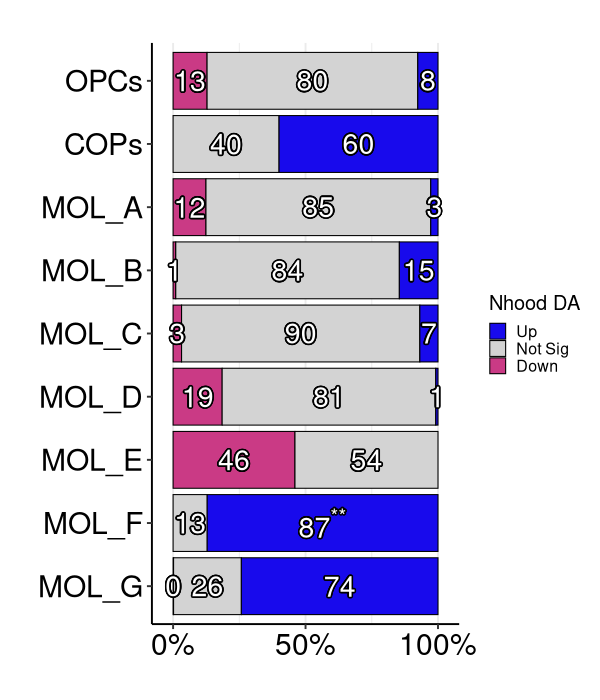

In [27]:
%%R -h 700 -w 600

## LR PLOT ##
# Define desired order
desired_order <- rev(c(
  "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data for LR
plot_df_LR <- CIL %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  )

# Filter results for LR and Up/Down only
sig_results_LR <- results %>%
  filter(condition_with_more == "CIL", sig_status %in% c("Up", "Down")) %>%
  select(nhood_annotation, sig_status, significance)

# Join and PRESERVE factor levels for LR
plot_df_with_labels_LR <- plot_df_LR %>% 
  left_join(
    sig_results_LR,
    by = c("nhood_annotation", "sig_status")
  ) %>%
  # Re-establish factor levels after join
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  ) %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup() %>%
    mutate(
        label = case_when(
          is.na(significance) ~ paste0("'", round(proportion * 100), "'"),
          significance == "* (p < 0.05)" ~ paste0("'", round(proportion * 100), "'^'*'"),
          significance == "** (p < 0.01)" ~ paste0("'", round(proportion * 100), "'^'**'"),
          TRUE ~ paste0("'", round(proportion * 100), "'")
        )
    )

# Plot stacked bar chart
p_LR <- ggplot(plot_df_with_labels_LR, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.9, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = label),
      parse = TRUE,
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.08,           # Radius of outline
      size = 10,
      fontface = "bold"
    ) +
  coord_flip() +
    scale_y_continuous(
      limits = c(0, 1),
      expand = expansion(mult = c(0.08, 0.08)),
      breaks = c(0, 0.5, 1),
      labels = scales::percent_format(accuracy = 1)
    ) +
  scale_fill_manual(
    values = c("Down" = "#CA3A85", "Not Sig" = "#D3D3D3", "Up" = "#180AEC"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 30),             # x-axis tick label size
    axis.text.y = element_text(size = 30),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("") +
  xlab("") +
  ggtitle("")

# Save the LR plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_CIL_remyel_SIG_UPDATED.png"),
  plot = p_LR,
  width = 10,
  height = 10,
  dpi = 300
)

# Display the LR plot
print(p_LR)

In [28]:
%%R -i AL -i NAWM

# Function to prepare a dataset
prepare_df <- function(df, condition_label) {
  df %>%
    mutate(
      sig_status = case_when(
        SpatialFDR < 0.1 & logFC > 0 ~ "Up",
        SpatialFDR < 0.1 & logFC < 0 ~ "Down",
        TRUE ~ "Not Sig"
      )
    ) %>%
    group_by(nhood_annotation, sig_status) %>%
    summarise(n = n(), .groups = "drop") %>%
    mutate(condition = condition_label)
}

# Main function to process two datasets and run tests
compare_conditions <- function(df1, df2, label1 = "Condition1", label2 = "Condition2", output_csv = NULL) {
  # Prepare both datasets
  df1_prepared <- prepare_df(df1, label1)
  df2_prepared <- prepare_df(df2, label2)
  
  # Combine
  combined_df <- bind_rows(df1_prepared, df2_prepared)
  
  # Compute totals per cell type and condition
  totals_df <- combined_df %>%
    group_by(nhood_annotation, condition) %>%
    summarise(total_n = sum(n), .groups = "drop")
  
  # Merge totals back
  combined_df <- combined_df %>%
    left_join(totals_df, by = c("nhood_annotation", "condition"))
  
  # Function to run Fisher or Chi-squared
  test_fn <- function(cell, status) {
    sub_df <- combined_df %>%
      filter(nhood_annotation == cell, sig_status == status)
    
    if (nrow(sub_df) != 2) {
      return(tibble(
        nhood_annotation = cell,
        sig_status = status,
        Condition1_count = NA,
        Condition1_total = NA,
        Condition1_prop = NA,
        Condition2_count = NA,
        Condition2_total = NA,
        Condition2_prop = NA,
        p_value = NA,
        test_used = NA
      ))
    }
    
    counts <- sub_df$n
    totals <- sub_df$total_n
    
    mat <- matrix(
      c(
        counts[1], totals[1] - counts[1],
        counts[2], totals[2] - counts[2]
      ),
      nrow = 2,
      byrow = TRUE
    )
    
    row_totals <- rowSums(mat)
    col_totals <- colSums(mat)
    grand_total <- sum(mat)
    expected <- outer(row_totals, col_totals) / grand_total
    
    if (any(expected < 5)) {
      test <- fisher.test(mat)
      test_name <- "Fisher"
    } else {
      test <- chisq.test(mat, simulate.p.value = FALSE, correct = FALSE)
      test_name <- "Chi-squared"
    }
    
    tibble(
      nhood_annotation = cell,
      sig_status = status,
      Condition1_count = counts[1],
      Condition1_total = totals[1],
      Condition1_prop = counts[1]/totals[1],
      Condition2_count = counts[2],
      Condition2_total = totals[2],
      Condition2_prop = counts[2]/totals[2],
      p_value = test$p.value,
      test_used = test_name
    )
  }
  
  # All unique combinations
  combinations <- combined_df %>%
    distinct(nhood_annotation, sig_status)
  
  # Run tests
  results <- pmap_dfr(
    list(combinations$nhood_annotation, combinations$sig_status),
    test_fn
  )
  
  # Adjust p-values
  results <- results %>%
    mutate(p_adj = p.adjust(p_value, method = "BH"))
  
  # Which condition has more
  results <- results %>%
    mutate(
      condition_with_more = case_when(
        is.na(Condition1_prop) | is.na(Condition2_prop) ~ NA_character_,
        Condition1_prop > Condition2_prop ~ label1,
        Condition1_prop < Condition2_prop ~ label2,
        Condition1_prop == Condition2_prop ~ "Equal"
      )
    )
  
  # Significance labels
  results <- results %>%
    mutate(
      significance = case_when(
        is.na(p_adj) ~ NA_character_,
        p_adj < 0.01 ~ "** (p < 0.01)",
        p_adj < 0.05 ~ "* (p < 0.05)",
        TRUE ~ ""
      )
    )
  
  # Output
  print(results, n = Inf)
  
  if (!is.null(output_csv)) {
    write.csv(results, output_csv, row.names = FALSE)
  }
  
  return(results)
}

# Run:
results <- compare_conditions(AL, NAWM, label1 = "AL", label2 = "NAWM", output_csv = "pairwise_fisher_chisq_results_AL_NAWM.csv")

# A tibble: 25 × 13
   nhood_annotation sig_status Condition1_count Condition1_total Condition1_prop
   <chr>            <chr>                 <int>            <int>           <dbl>
 1 COPs             Not Sig                   2               15          0.133 
 2 COPs             Up                       NA               NA         NA     
 3 MOL_A            Down                    854             2087          0.409 
 4 MOL_A            Not Sig                1097             2087          0.526 
 5 MOL_A            Up                      136             2087          0.0652
 6 MOL_B            Down                    501             3558          0.141 
 7 MOL_B            Not Sig                2271             3558          0.638 
 8 MOL_B            Up                      786             3558          0.221 
 9 MOL_C            Down                    319             2845          0.112 
10 MOL_C            Not Sig                2071             2845          0.728 
11 MOL_C

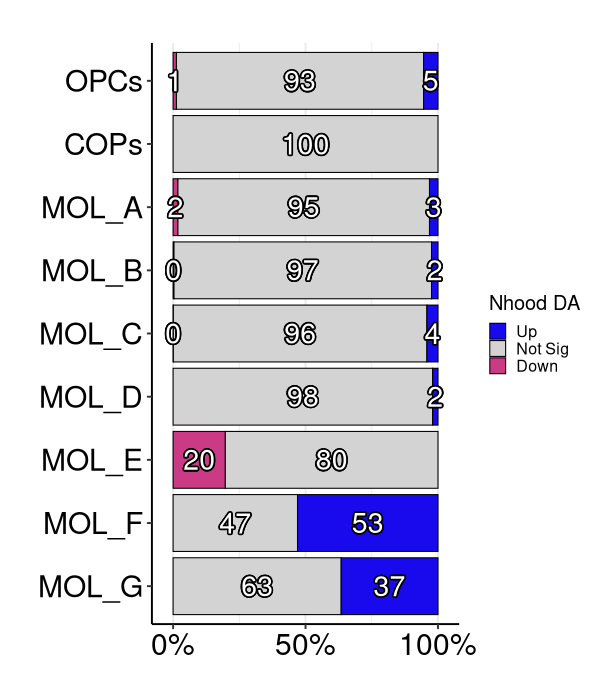

In [29]:
%%R -h 700 -w 600

## LR PLOT ##
# Define desired order
desired_order <- rev(c(
  "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data for LR
plot_df_LR <- NAWM %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  )

# Filter results for LR and Up/Down only
sig_results_LR <- results %>%
  filter(condition_with_more == "NAWM", sig_status %in% c("Up", "Down")) %>%
  select(nhood_annotation, sig_status, significance)

# Join and PRESERVE factor levels for LR
plot_df_with_labels_LR <- plot_df_LR %>% 
  left_join(
    sig_results_LR,
    by = c("nhood_annotation", "sig_status")
  ) %>%
  # Re-establish factor levels after join
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  ) %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup() %>%
    mutate(
        label = case_when(
          is.na(significance) ~ paste0("'", round(proportion * 100), "'"),
          significance == "* (p < 0.05)" ~ paste0("'", round(proportion * 100), "'^'*'"),
          significance == "** (p < 0.01)" ~ paste0("'", round(proportion * 100), "'^'**'"),
          TRUE ~ paste0("'", round(proportion * 100), "'")
        )
    )

# Plot stacked bar chart
p_LR <- ggplot(plot_df_with_labels_LR, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.9, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = label),
      parse = TRUE,
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.08,           # Radius of outline
      size = 10,
      fontface = "bold"
    ) +
  coord_flip() +
    scale_y_continuous(
      limits = c(0, 1),
      expand = expansion(mult = c(0.08, 0.08)),
      breaks = c(0, 0.5, 1),
      labels = scales::percent_format(accuracy = 1)
    ) +
  scale_fill_manual(
    values = c("Down" = "#CA3A85", "Not Sig" = "#D3D3D3", "Up" = "#180AEC"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 30),             # x-axis tick label size
    axis.text.y = element_text(size = 30),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("") +
  xlab("") +
  ggtitle("")

# Save the LR plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_NAWM_remyel_SIG_UPDATED.png"),
  plot = p_LR,
  width = 10,
  height = 10,
  dpi = 300
)

# Display the LR plot
print(p_LR)

# Try comparing NAWM vs all

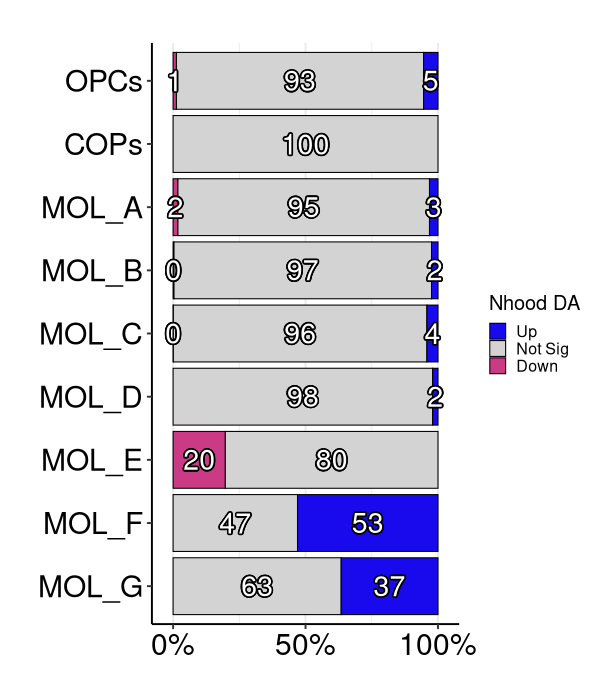

In [35]:
%%R -h 700 -w 600

## LR PLOT ##
# Define desired order
desired_order <- rev(c(
  "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data for LR
plot_df_LR <- NAWM %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  )

# Filter results for LR and Up/Down only
sig_results_LR <- results %>%
  filter(condition_with_more == "NAWM", sig_status %in% c("Up", "Down")) %>%
  select(nhood_annotation, sig_status, significance)

# Join and PRESERVE factor levels for LR
plot_df_with_labels_LR <- plot_df_LR %>% 
  left_join(
    sig_results_LR,
    by = c("nhood_annotation", "sig_status")
  ) %>%
  # Re-establish factor levels after join
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  ) %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup() %>%
    mutate(
        label = paste0("'", round(proportion * 100), "'")
    )

# Plot stacked bar chart
p_LR <- ggplot(plot_df_with_labels_LR, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.9, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = label),
      parse = TRUE,
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.08,           # Radius of outline
      size = 10,
      fontface = "bold"
    ) +
  coord_flip() +
    scale_y_continuous(
      limits = c(0, 1),
      expand = expansion(mult = c(0.08, 0.08)),
      breaks = c(0, 0.5, 1),
      labels = scales::percent_format(accuracy = 1)
    ) +
  scale_fill_manual(
    values = c("Down" = "#CA3A85", "Not Sig" = "#D3D3D3", "Up" = "#180AEC"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 30),             # x-axis tick label size
    axis.text.y = element_text(size = 30),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("") +
  xlab("") +
  ggtitle("")

# Save the LR plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_NAWM.png"),
  plot = p_LR,
  width = 10,
  height = 10,
  dpi = 300
)

# Display the LR plot
print(p_LR)

In [38]:
%%R

# Function to prepare a dataset
prepare_df <- function(df, condition_label) {
  df %>%
    mutate(
      sig_status = case_when(
        SpatialFDR < 0.1 & logFC > 0 ~ "Up",
        SpatialFDR < 0.1 & logFC < 0 ~ "Down",
        TRUE ~ "Not Sig"
      )
    ) %>%
    group_by(nhood_annotation, sig_status) %>%
    summarise(n = n(), .groups = "drop") %>%
    mutate(condition = condition_label)
}

# Main function to process two datasets and run tests
compare_conditions <- function(df1, df2, label1 = "Condition1", label2 = "Condition2", output_csv = NULL) {
  # Prepare both datasets
  df1_prepared <- prepare_df(df1, label1)
  df2_prepared <- prepare_df(df2, label2)
  
  # Combine
  combined_df <- bind_rows(df1_prepared, df2_prepared)
  
  # Compute totals per cell type and condition
  totals_df <- combined_df %>%
    group_by(nhood_annotation, condition) %>%
    summarise(total_n = sum(n), .groups = "drop")
  
  # Merge totals back
  combined_df <- combined_df %>%
    left_join(totals_df, by = c("nhood_annotation", "condition"))
  
  # Function to run Fisher or Chi-squared
  test_fn <- function(cell, status) {
    sub_df <- combined_df %>%
      filter(nhood_annotation == cell, sig_status == status)
    
    if (nrow(sub_df) != 2) {
      return(tibble(
        nhood_annotation = cell,
        sig_status = status,
        Condition1_count = NA,
        Condition1_total = NA,
        Condition1_prop = NA,
        Condition2_count = NA,
        Condition2_total = NA,
        Condition2_prop = NA,
        p_value = NA,
        test_used = NA
      ))
    }
    
    counts <- sub_df$n
    totals <- sub_df$total_n
    
    mat <- matrix(
      c(
        counts[1], totals[1] - counts[1],
        counts[2], totals[2] - counts[2]
      ),
      nrow = 2,
      byrow = TRUE
    )
    
    row_totals <- rowSums(mat)
    col_totals <- colSums(mat)
    grand_total <- sum(mat)
    expected <- outer(row_totals, col_totals) / grand_total
    
    if (any(expected < 5)) {
      test <- fisher.test(mat)
      test_name <- "Fisher"
    } else {
      test <- chisq.test(mat, simulate.p.value = FALSE, correct = FALSE)
      test_name <- "Chi-squared"
    }
    
    tibble(
      nhood_annotation = cell,
      sig_status = status,
      Condition1_count = counts[1],
      Condition1_total = totals[1],
      Condition1_prop = counts[1]/totals[1],
      Condition2_count = counts[2],
      Condition2_total = totals[2],
      Condition2_prop = counts[2]/totals[2],
      p_value = test$p.value,
      test_used = test_name
    )
  }
  
  # All unique combinations
  combinations <- combined_df %>%
    distinct(nhood_annotation, sig_status)
  
  # Run tests
  results <- pmap_dfr(
    list(combinations$nhood_annotation, combinations$sig_status),
    test_fn
  )
  
  # Adjust p-values
  results <- results %>%
    mutate(p_adj = p.adjust(p_value, method = "BH"))
  
  # Which condition has more
  results <- results %>%
    mutate(
      condition_with_more = case_when(
        is.na(Condition1_prop) | is.na(Condition2_prop) ~ NA_character_,
        Condition1_prop > Condition2_prop ~ label1,
        Condition1_prop < Condition2_prop ~ label2,
        Condition1_prop == Condition2_prop ~ "Equal"
      )
    )
  
  # Significance labels
  results <- results %>%
    mutate(
      significance = case_when(
        is.na(p_adj) ~ NA_character_,
        p_adj < 0.01 ~ "** (p < 0.01)",
        p_adj < 0.05 ~ "* (p < 0.05)",
        TRUE ~ ""
      )
    )
  
  # Output
  print(results, n = Inf)
  
  if (!is.null(output_csv)) {
    write.csv(results, output_csv, row.names = FALSE)
  }
  
  return(results)
}

# Run:
results <- compare_conditions(AL, NAWM, label1 = "AL", label2 = "NAWM", output_csv = "pairwise_fisher_chisq_results_NAWM_AL.csv")

# A tibble: 25 × 13
   nhood_annotation sig_status Condition1_count Condition1_total Condition1_prop
   <chr>            <chr>                 <int>            <int>           <dbl>
 1 COPs             Not Sig                   2               15          0.133 
 2 COPs             Up                       NA               NA         NA     
 3 MOL_A            Down                    854             2087          0.409 
 4 MOL_A            Not Sig                1097             2087          0.526 
 5 MOL_A            Up                      136             2087          0.0652
 6 MOL_B            Down                    501             3558          0.141 
 7 MOL_B            Not Sig                2271             3558          0.638 
 8 MOL_B            Up                      786             3558          0.221 
 9 MOL_C            Down                    319             2845          0.112 
10 MOL_C            Not Sig                2071             2845          0.728 
11 MOL_C

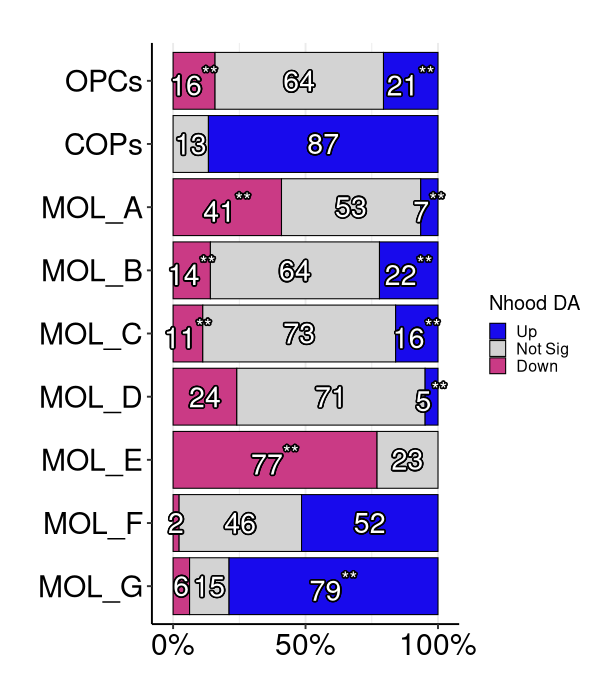

In [39]:
%%R -h 700 -w 600

## LR PLOT ##
# Define desired order
desired_order <- rev(c(
  "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data for LR
plot_df_LR <- AL %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  )

# Filter results for LR and Up/Down only
sig_results_LR <- results %>%
  filter(condition_with_more == "AL", sig_status %in% c("Up", "Down")) %>%
  select(nhood_annotation, sig_status, significance)

# Join and PRESERVE factor levels for LR
plot_df_with_labels_LR <- plot_df_LR %>% 
  left_join(
    sig_results_LR,
    by = c("nhood_annotation", "sig_status")
  ) %>%
  # Re-establish factor levels after join
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  ) %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup() %>%
    mutate(
        label = case_when(
          is.na(significance) ~ paste0("'", round(proportion * 100), "'"),
          significance == "* (p < 0.05)" ~ paste0("'", round(proportion * 100), "'^'*'"),
          significance == "** (p < 0.01)" ~ paste0("'", round(proportion * 100), "'^'**'"),
          TRUE ~ paste0("'", round(proportion * 100), "'")
        )
    )

# Plot stacked bar chart
p_LR <- ggplot(plot_df_with_labels_LR, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.9, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = label),
      parse = TRUE,
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.08,           # Radius of outline
      size = 10,
      fontface = "bold"
    ) +
  coord_flip() +
    scale_y_continuous(
      limits = c(0, 1),
      expand = expansion(mult = c(0.08, 0.08)),
      breaks = c(0, 0.5, 1),
      labels = scales::percent_format(accuracy = 1)
    ) +
  scale_fill_manual(
    values = c("Down" = "#CA3A85", "Not Sig" = "#D3D3D3", "Up" = "#180AEC"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 30),             # x-axis tick label size
    axis.text.y = element_text(size = 30),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("") +
  xlab("") +
  ggtitle("")

# Save the LR plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_AL_vNAWM_.png"),
  plot = p_LR,
  width = 10,
  height = 10,
  dpi = 300
)

# Display the LR plot
print(p_LR)

In [40]:
%%R

# Function to prepare a dataset
prepare_df <- function(df, condition_label) {
  df %>%
    mutate(
      sig_status = case_when(
        SpatialFDR < 0.1 & logFC > 0 ~ "Up",
        SpatialFDR < 0.1 & logFC < 0 ~ "Down",
        TRUE ~ "Not Sig"
      )
    ) %>%
    group_by(nhood_annotation, sig_status) %>%
    summarise(n = n(), .groups = "drop") %>%
    mutate(condition = condition_label)
}

# Main function to process two datasets and run tests
compare_conditions <- function(df1, df2, label1 = "Condition1", label2 = "Condition2", output_csv = NULL) {
  # Prepare both datasets
  df1_prepared <- prepare_df(df1, label1)
  df2_prepared <- prepare_df(df2, label2)
  
  # Combine
  combined_df <- bind_rows(df1_prepared, df2_prepared)
  
  # Compute totals per cell type and condition
  totals_df <- combined_df %>%
    group_by(nhood_annotation, condition) %>%
    summarise(total_n = sum(n), .groups = "drop")
  
  # Merge totals back
  combined_df <- combined_df %>%
    left_join(totals_df, by = c("nhood_annotation", "condition"))
  
  # Function to run Fisher or Chi-squared
  test_fn <- function(cell, status) {
    sub_df <- combined_df %>%
      filter(nhood_annotation == cell, sig_status == status)
    
    if (nrow(sub_df) != 2) {
      return(tibble(
        nhood_annotation = cell,
        sig_status = status,
        Condition1_count = NA,
        Condition1_total = NA,
        Condition1_prop = NA,
        Condition2_count = NA,
        Condition2_total = NA,
        Condition2_prop = NA,
        p_value = NA,
        test_used = NA
      ))
    }
    
    counts <- sub_df$n
    totals <- sub_df$total_n
    
    mat <- matrix(
      c(
        counts[1], totals[1] - counts[1],
        counts[2], totals[2] - counts[2]
      ),
      nrow = 2,
      byrow = TRUE
    )
    
    row_totals <- rowSums(mat)
    col_totals <- colSums(mat)
    grand_total <- sum(mat)
    expected <- outer(row_totals, col_totals) / grand_total
    
    if (any(expected < 5)) {
      test <- fisher.test(mat)
      test_name <- "Fisher"
    } else {
      test <- chisq.test(mat, simulate.p.value = FALSE, correct = FALSE)
      test_name <- "Chi-squared"
    }
    
    tibble(
      nhood_annotation = cell,
      sig_status = status,
      Condition1_count = counts[1],
      Condition1_total = totals[1],
      Condition1_prop = counts[1]/totals[1],
      Condition2_count = counts[2],
      Condition2_total = totals[2],
      Condition2_prop = counts[2]/totals[2],
      p_value = test$p.value,
      test_used = test_name
    )
  }
  
  # All unique combinations
  combinations <- combined_df %>%
    distinct(nhood_annotation, sig_status)
  
  # Run tests
  results <- pmap_dfr(
    list(combinations$nhood_annotation, combinations$sig_status),
    test_fn
  )
  
  # Adjust p-values
  results <- results %>%
    mutate(p_adj = p.adjust(p_value, method = "BH"))
  
  # Which condition has more
  results <- results %>%
    mutate(
      condition_with_more = case_when(
        is.na(Condition1_prop) | is.na(Condition2_prop) ~ NA_character_,
        Condition1_prop > Condition2_prop ~ label1,
        Condition1_prop < Condition2_prop ~ label2,
        Condition1_prop == Condition2_prop ~ "Equal"
      )
    )
  
  # Significance labels
  results <- results %>%
    mutate(
      significance = case_when(
        is.na(p_adj) ~ NA_character_,
        p_adj < 0.01 ~ "** (p < 0.01)",
        p_adj < 0.05 ~ "* (p < 0.05)",
        TRUE ~ ""
      )
    )
  
  # Output
  print(results, n = Inf)
  
  if (!is.null(output_csv)) {
    write.csv(results, output_csv, row.names = FALSE)
  }
  
  return(results)
}

# Run:
results <- compare_conditions(CAL, NAWM, label1 = "CAL", label2 = "NAWM", output_csv = "pairwise_fisher_chisq_results_NAWM_CAL.csv")

# A tibble: 25 × 13
   nhood_annotation sig_status Condition1_count Condition1_total Condition1_prop
   <chr>            <chr>                 <int>            <int>           <dbl>
 1 COPs             Not Sig                   5               15          0.333 
 2 COPs             Up                       NA               NA         NA     
 3 MOL_A            Down                    463             2087          0.222 
 4 MOL_A            Not Sig                1384             2087          0.663 
 5 MOL_A            Up                      240             2087          0.115 
 6 MOL_B            Down                    684             3558          0.192 
 7 MOL_B            Not Sig                2081             3558          0.585 
 8 MOL_B            Up                      793             3558          0.223 
 9 MOL_C            Down                    650             2845          0.228 
10 MOL_C            Not Sig                1784             2845          0.627 
11 MOL_C

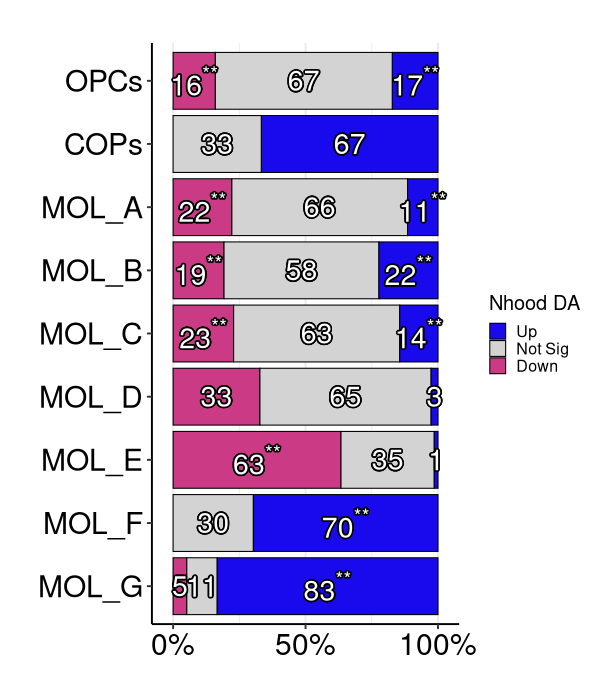

In [41]:
%%R -h 700 -w 600

## LR PLOT ##
# Define desired order
desired_order <- rev(c(
  "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data for LR
plot_df_LR <- CAL %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  )

# Filter results for LR and Up/Down only
sig_results_LR <- results %>%
  filter(condition_with_more == "CAL", sig_status %in% c("Up", "Down")) %>%
  select(nhood_annotation, sig_status, significance)

# Join and PRESERVE factor levels for LR
plot_df_with_labels_LR <- plot_df_LR %>% 
  left_join(
    sig_results_LR,
    by = c("nhood_annotation", "sig_status")
  ) %>%
  # Re-establish factor levels after join
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  ) %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup() %>%
    mutate(
        label = case_when(
          is.na(significance) ~ paste0("'", round(proportion * 100), "'"),
          significance == "* (p < 0.05)" ~ paste0("'", round(proportion * 100), "'^'*'"),
          significance == "** (p < 0.01)" ~ paste0("'", round(proportion * 100), "'^'**'"),
          TRUE ~ paste0("'", round(proportion * 100), "'")
        )
    )

# Plot stacked bar chart
p_LR <- ggplot(plot_df_with_labels_LR, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.9, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = label),
      parse = TRUE,
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.08,           # Radius of outline
      size = 10,
      fontface = "bold"
    ) +
  coord_flip() +
    scale_y_continuous(
      limits = c(0, 1),
      expand = expansion(mult = c(0.08, 0.08)),
      breaks = c(0, 0.5, 1),
      labels = scales::percent_format(accuracy = 1)
    ) +
  scale_fill_manual(
    values = c("Down" = "#CA3A85", "Not Sig" = "#D3D3D3", "Up" = "#180AEC"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 30),             # x-axis tick label size
    axis.text.y = element_text(size = 30),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("") +
  xlab("") +
  ggtitle("")

# Save the LR plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_CAL_vNAWM.png"),
  plot = p_LR,
  width = 10,
  height = 10,
  dpi = 300
)

# Display the LR plot
print(p_LR)

In [42]:
%%R

# Function to prepare a dataset
prepare_df <- function(df, condition_label) {
  df %>%
    mutate(
      sig_status = case_when(
        SpatialFDR < 0.1 & logFC > 0 ~ "Up",
        SpatialFDR < 0.1 & logFC < 0 ~ "Down",
        TRUE ~ "Not Sig"
      )
    ) %>%
    group_by(nhood_annotation, sig_status) %>%
    summarise(n = n(), .groups = "drop") %>%
    mutate(condition = condition_label)
}

# Main function to process two datasets and run tests
compare_conditions <- function(df1, df2, label1 = "Condition1", label2 = "Condition2", output_csv = NULL) {
  # Prepare both datasets
  df1_prepared <- prepare_df(df1, label1)
  df2_prepared <- prepare_df(df2, label2)
  
  # Combine
  combined_df <- bind_rows(df1_prepared, df2_prepared)
  
  # Compute totals per cell type and condition
  totals_df <- combined_df %>%
    group_by(nhood_annotation, condition) %>%
    summarise(total_n = sum(n), .groups = "drop")
  
  # Merge totals back
  combined_df <- combined_df %>%
    left_join(totals_df, by = c("nhood_annotation", "condition"))
  
  # Function to run Fisher or Chi-squared
  test_fn <- function(cell, status) {
    sub_df <- combined_df %>%
      filter(nhood_annotation == cell, sig_status == status)
    
    if (nrow(sub_df) != 2) {
      return(tibble(
        nhood_annotation = cell,
        sig_status = status,
        Condition1_count = NA,
        Condition1_total = NA,
        Condition1_prop = NA,
        Condition2_count = NA,
        Condition2_total = NA,
        Condition2_prop = NA,
        p_value = NA,
        test_used = NA
      ))
    }
    
    counts <- sub_df$n
    totals <- sub_df$total_n
    
    mat <- matrix(
      c(
        counts[1], totals[1] - counts[1],
        counts[2], totals[2] - counts[2]
      ),
      nrow = 2,
      byrow = TRUE
    )
    
    row_totals <- rowSums(mat)
    col_totals <- colSums(mat)
    grand_total <- sum(mat)
    expected <- outer(row_totals, col_totals) / grand_total
    
    if (any(expected < 5)) {
      test <- fisher.test(mat)
      test_name <- "Fisher"
    } else {
      test <- chisq.test(mat, simulate.p.value = FALSE, correct = FALSE)
      test_name <- "Chi-squared"
    }
    
    tibble(
      nhood_annotation = cell,
      sig_status = status,
      Condition1_count = counts[1],
      Condition1_total = totals[1],
      Condition1_prop = counts[1]/totals[1],
      Condition2_count = counts[2],
      Condition2_total = totals[2],
      Condition2_prop = counts[2]/totals[2],
      p_value = test$p.value,
      test_used = test_name
    )
  }
  
  # All unique combinations
  combinations <- combined_df %>%
    distinct(nhood_annotation, sig_status)
  
  # Run tests
  results <- pmap_dfr(
    list(combinations$nhood_annotation, combinations$sig_status),
    test_fn
  )
  
  # Adjust p-values
  results <- results %>%
    mutate(p_adj = p.adjust(p_value, method = "BH"))
  
  # Which condition has more
  results <- results %>%
    mutate(
      condition_with_more = case_when(
        is.na(Condition1_prop) | is.na(Condition2_prop) ~ NA_character_,
        Condition1_prop > Condition2_prop ~ label1,
        Condition1_prop < Condition2_prop ~ label2,
        Condition1_prop == Condition2_prop ~ "Equal"
      )
    )
  
  # Significance labels
  results <- results %>%
    mutate(
      significance = case_when(
        is.na(p_adj) ~ NA_character_,
        p_adj < 0.01 ~ "** (p < 0.01)",
        p_adj < 0.05 ~ "* (p < 0.05)",
        TRUE ~ ""
      )
    )
  
  # Output
  print(results, n = Inf)
  
  if (!is.null(output_csv)) {
    write.csv(results, output_csv, row.names = FALSE)
  }
  
  return(results)
}

# Run:
results <- compare_conditions(CIL, NAWM, label1 = "CIL", label2 = "NAWM", output_csv = "pairwise_fisher_chisq_results_NAWM_CIL.csv")

# A tibble: 24 × 13
   nhood_annotation sig_status Condition1_count Condition1_total Condition1_prop
   <chr>            <chr>                 <int>            <int>           <dbl>
 1 COPs             Not Sig                   6               15         0.4    
 2 COPs             Up                       NA               NA        NA      
 3 MOL_A            Down                    259             2087         0.124  
 4 MOL_A            Not Sig                1771             2087         0.849  
 5 MOL_A            Up                       57             2087         0.0273 
 6 MOL_B            Down                     36             3558         0.0101 
 7 MOL_B            Not Sig                3003             3558         0.844  
 8 MOL_B            Up                      519             3558         0.146  
 9 MOL_C            Down                     91             2845         0.0320 
10 MOL_C            Not Sig                2559             2845         0.899  
11 MOL_C

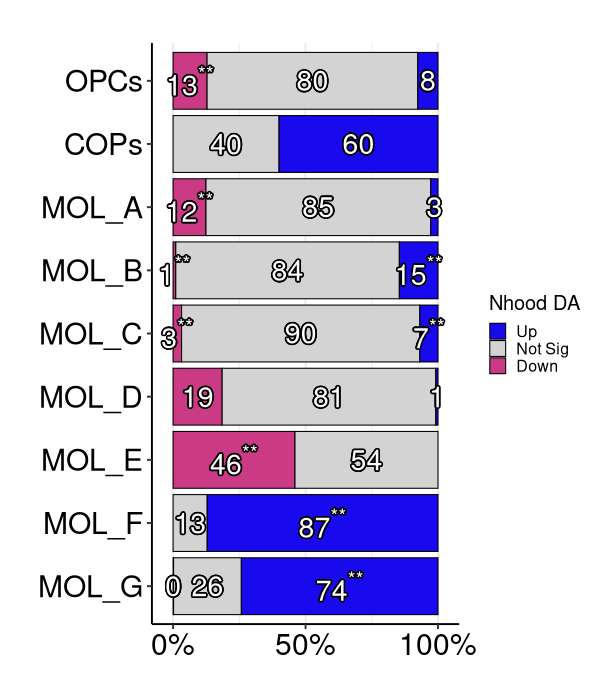

In [43]:
%%R -h 700 -w 600

## LR PLOT ##
# Define desired order
desired_order <- rev(c(
  "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data for LR
plot_df_LR <- CIL %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  )

# Filter results for LR and Up/Down only
sig_results_LR <- results %>%
  filter(condition_with_more == "CIL", sig_status %in% c("Up", "Down")) %>%
  select(nhood_annotation, sig_status, significance)

# Join and PRESERVE factor levels for LR
plot_df_with_labels_LR <- plot_df_LR %>% 
  left_join(
    sig_results_LR,
    by = c("nhood_annotation", "sig_status")
  ) %>%
  # Re-establish factor levels after join
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  ) %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup() %>%
    mutate(
        label = case_when(
          is.na(significance) ~ paste0("'", round(proportion * 100), "'"),
          significance == "* (p < 0.05)" ~ paste0("'", round(proportion * 100), "'^'*'"),
          significance == "** (p < 0.01)" ~ paste0("'", round(proportion * 100), "'^'**'"),
          TRUE ~ paste0("'", round(proportion * 100), "'")
        )
    )

# Plot stacked bar chart
p_LR <- ggplot(plot_df_with_labels_LR, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.9, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = label),
      parse = TRUE,
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.08,           # Radius of outline
      size = 10,
      fontface = "bold"
    ) +
  coord_flip() +
    scale_y_continuous(
      limits = c(0, 1),
      expand = expansion(mult = c(0.08, 0.08)),
      breaks = c(0, 0.5, 1),
      labels = scales::percent_format(accuracy = 1)
    ) +
  scale_fill_manual(
    values = c("Down" = "#CA3A85", "Not Sig" = "#D3D3D3", "Up" = "#180AEC"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 30),             # x-axis tick label size
    axis.text.y = element_text(size = 30),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("") +
  xlab("") +
  ggtitle("")

# Save the LR plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_CIL_vNAWM.png"),
  plot = p_LR,
  width = 10,
  height = 10,
  dpi = 300
)

# Display the LR plot
print(p_LR)

In [44]:
%%R -i AL -i NAWM

# Function to prepare a dataset
prepare_df <- function(df, condition_label) {
  df %>%
    mutate(
      sig_status = case_when(
        SpatialFDR < 0.1 & logFC > 0 ~ "Up",
        SpatialFDR < 0.1 & logFC < 0 ~ "Down",
        TRUE ~ "Not Sig"
      )
    ) %>%
    group_by(nhood_annotation, sig_status) %>%
    summarise(n = n(), .groups = "drop") %>%
    mutate(condition = condition_label)
}

# Main function to process two datasets and run tests
compare_conditions <- function(df1, df2, label1 = "Condition1", label2 = "Condition2", output_csv = NULL) {
  # Prepare both datasets
  df1_prepared <- prepare_df(df1, label1)
  df2_prepared <- prepare_df(df2, label2)
  
  # Combine
  combined_df <- bind_rows(df1_prepared, df2_prepared)
  
  # Compute totals per cell type and condition
  totals_df <- combined_df %>%
    group_by(nhood_annotation, condition) %>%
    summarise(total_n = sum(n), .groups = "drop")
  
  # Merge totals back
  combined_df <- combined_df %>%
    left_join(totals_df, by = c("nhood_annotation", "condition"))
  
  # Function to run Fisher or Chi-squared
  test_fn <- function(cell, status) {
    sub_df <- combined_df %>%
      filter(nhood_annotation == cell, sig_status == status)
    
    if (nrow(sub_df) != 2) {
      return(tibble(
        nhood_annotation = cell,
        sig_status = status,
        Condition1_count = NA,
        Condition1_total = NA,
        Condition1_prop = NA,
        Condition2_count = NA,
        Condition2_total = NA,
        Condition2_prop = NA,
        p_value = NA,
        test_used = NA
      ))
    }
    
    counts <- sub_df$n
    totals <- sub_df$total_n
    
    mat <- matrix(
      c(
        counts[1], totals[1] - counts[1],
        counts[2], totals[2] - counts[2]
      ),
      nrow = 2,
      byrow = TRUE
    )
    
    row_totals <- rowSums(mat)
    col_totals <- colSums(mat)
    grand_total <- sum(mat)
    expected <- outer(row_totals, col_totals) / grand_total
    
    if (any(expected < 5)) {
      test <- fisher.test(mat)
      test_name <- "Fisher"
    } else {
      test <- chisq.test(mat, simulate.p.value = FALSE, correct = FALSE)
      test_name <- "Chi-squared"
    }
    
    tibble(
      nhood_annotation = cell,
      sig_status = status,
      Condition1_count = counts[1],
      Condition1_total = totals[1],
      Condition1_prop = counts[1]/totals[1],
      Condition2_count = counts[2],
      Condition2_total = totals[2],
      Condition2_prop = counts[2]/totals[2],
      p_value = test$p.value,
      test_used = test_name
    )
  }
  
  # All unique combinations
  combinations <- combined_df %>%
    distinct(nhood_annotation, sig_status)
  
  # Run tests
  results <- pmap_dfr(
    list(combinations$nhood_annotation, combinations$sig_status),
    test_fn
  )
  
  # Adjust p-values
  results <- results %>%
    mutate(p_adj = p.adjust(p_value, method = "BH"))
  
  # Which condition has more
  results <- results %>%
    mutate(
      condition_with_more = case_when(
        is.na(Condition1_prop) | is.na(Condition2_prop) ~ NA_character_,
        Condition1_prop > Condition2_prop ~ label1,
        Condition1_prop < Condition2_prop ~ label2,
        Condition1_prop == Condition2_prop ~ "Equal"
      )
    )
  
  # Significance labels
  results <- results %>%
    mutate(
      significance = case_when(
        is.na(p_adj) ~ NA_character_,
        p_adj < 0.01 ~ "** (p < 0.01)",
        p_adj < 0.05 ~ "* (p < 0.05)",
        TRUE ~ ""
      )
    )
  
  # Output
  print(results, n = Inf)
  
  if (!is.null(output_csv)) {
    write.csv(results, output_csv, row.names = FALSE)
  }
  
  return(results)
}

# Run:
results <- compare_conditions(RL, NAWM, label1 = "RL", label2 = "NAWM", output_csv = "pairwise_fisher_chisq_results_NAWM_RL.csv")

# A tibble: 23 × 13
   nhood_annotation sig_status Condition1_count Condition1_total Condition1_prop
   <chr>            <chr>                 <int>            <int>           <dbl>
 1 COPs             Not Sig                  15               15         1      
 2 MOL_A            Down                    235             2087         0.113  
 3 MOL_A            Not Sig                1725             2087         0.827  
 4 MOL_A            Up                      127             2087         0.0609 
 5 MOL_B            Down                      5             3558         0.00141
 6 MOL_B            Not Sig                2937             3558         0.825  
 7 MOL_B            Up                      616             3558         0.173  
 8 MOL_C            Down                     19             2845         0.00668
 9 MOL_C            Not Sig                2627             2845         0.923  
10 MOL_C            Up                      199             2845         0.0699 
11 MOL_D

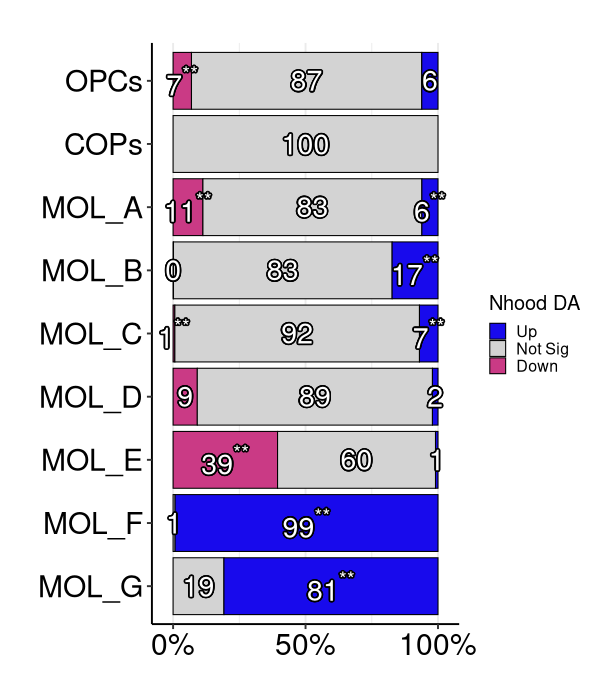

In [45]:
%%R -h 700 -w 600

## LR PLOT ##
# Define desired order
desired_order <- rev(c(
  "OPCs", "COPs", "NFOLs", "MFOLs","MOL_A", "MOL_B", "MOL_C", "MOL_D", "MOL_E", "MOL_F", "MOL_G"
))

# Process data for LR
plot_df_LR <- RL %>%
  mutate(
    sig_status = case_when(
      SpatialFDR < 0.1 & logFC > 0 ~ "Up",
      SpatialFDR < 0.1 & logFC < 0 ~ "Down",
      TRUE ~ "Not Sig"
    )
  ) %>%
  group_by(nhood_annotation, sig_status) %>%
  summarise(n = n(), .groups = "drop") %>%
  group_by(nhood_annotation) %>%
  mutate(
    proportion = n / sum(n)
  ) %>%
  ungroup() %>%
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  )

# Filter results for LR and Up/Down only
sig_results_LR <- results %>%
  filter(condition_with_more == "RL", sig_status %in% c("Up", "Down")) %>%
  select(nhood_annotation, sig_status, significance)

# Join and PRESERVE factor levels for LR
plot_df_with_labels_LR <- plot_df_LR %>% 
  left_join(
    sig_results_LR,
    by = c("nhood_annotation", "sig_status")
  ) %>%
  # Re-establish factor levels after join
  mutate(
    nhood_annotation = factor(nhood_annotation, levels = desired_order),
    sig_status = factor(sig_status, levels = c("Up", "Not Sig", "Down"))
  ) %>%
  group_by(nhood_annotation) %>%
  arrange(desc(sig_status)) %>%
  mutate(
    cumulative = cumsum(proportion),
    midpoint = cumulative - proportion / 2
  ) %>%
  ungroup() %>%
    mutate(
        label = case_when(
          is.na(significance) ~ paste0("'", round(proportion * 100), "'"),
          significance == "* (p < 0.05)" ~ paste0("'", round(proportion * 100), "'^'*'"),
          significance == "** (p < 0.01)" ~ paste0("'", round(proportion * 100), "'^'**'"),
          TRUE ~ paste0("'", round(proportion * 100), "'")
        )
    )

# Plot stacked bar chart
p_LR <- ggplot(plot_df_with_labels_LR, aes(x = nhood_annotation, y = proportion, fill = sig_status)) +
  geom_col(width = 0.9, color = "black") +
    geom_shadowtext(
      aes(y = midpoint, label = label),
      parse = TRUE,
      color = "white",       # Text color
      bg.color = "black",    # Outline color
      bg.r = 0.08,           # Radius of outline
      size = 10,
      fontface = "bold"
    ) +
  coord_flip() +
    scale_y_continuous(
      limits = c(0, 1),
      expand = expansion(mult = c(0.08, 0.08)),
      breaks = c(0, 0.5, 1),
      labels = scales::percent_format(accuracy = 1)
    ) +
  scale_fill_manual(
    values = c("Down" = "#CA3A85", "Not Sig" = "#D3D3D3", "Up" = "#180AEC"),
    name = "Nhood DA"
  ) +
  theme_bw(base_size = 20) +
  theme(
    panel.border = element_blank(),   # remove outer box
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line = element_line(color = "black"),  # keep axes
    legend.position = "right",
    axis.text = element_text(color = "black"),
    axis.title = element_text(color = "black"),
    axis.text.x = element_text(size = 30),             # x-axis tick label size
    axis.text.y = element_text(size = 30),             # y-axis tick label size
    axis.title.x = element_text(size = 24),            # x-axis label size
    axis.title.y = element_text(size = 24),            # y-axis label size
    legend.text = element_text(color = "black"),
    legend.title = element_text(color = "black"),
    plot.title = element_text(color = "black")
  ) +
  ylab("") +
  xlab("") +
  ggtitle("")

# Save the LR plot
ggsave(
  paste0(figdir, "stacked_bar_sig_proportions_RL_vNAWM.png"),
  plot = p_LR,
  width = 10,
  height = 10,
  dpi = 300
)

# Display the LR plot
print(p_LR)